Detected classes: 9
Detected colors: [(0, 0, 0), (0, 0, 255), (0, 128, 0), (0, 255, 0), (0, 255, 255), (128, 128, 0), (255, 0, 0), (255, 0, 255), (255, 255, 0)]
Label names: ['BG', 'NFL', 'GCL+IPL', 'INL', 'OPL', 'ONL', 'ELM+IS', 'OS', 'RPE']
Loading dataset...
Loaded test images: (40, 384, 256, 3), masks: (40, 384, 256)

Loading model...

===== Model Complexity =====
Total Parameters : 7,369,403
Weight Memory    : 28.11 MB
FLOPs            : 45.51 GFLOPs

Running inference...
40/40 [==============================] - 2s 23ms/step

===== Inference Performance =====
Total Time       : 2.6498 sec
Time per Image   : 66.25 ms
FPS              : 15.10

===== NR206-STYLE RESULTS (mean ± std, %) =====
--------------------------------------------------------------------------------
Layer        Dice (%)             IoU (%)              PA (%)              
--------------------------------------------------------------------------------
NFL          86.35 ± 3.87 76.18 ± 5.83        87.58 ± 5.77


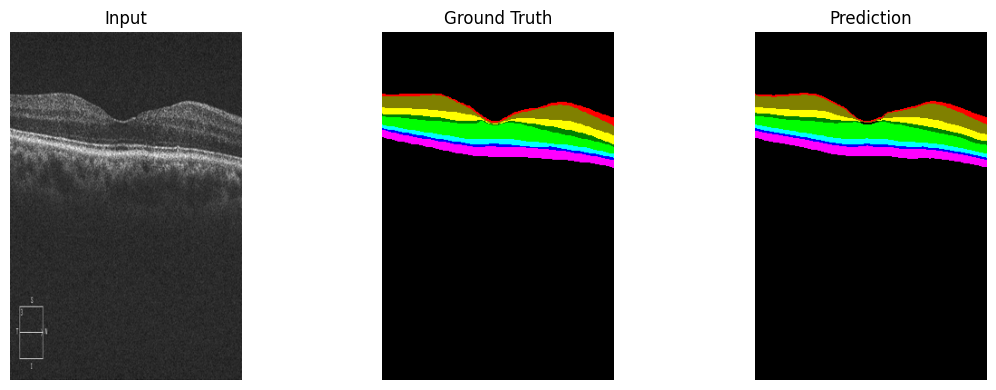

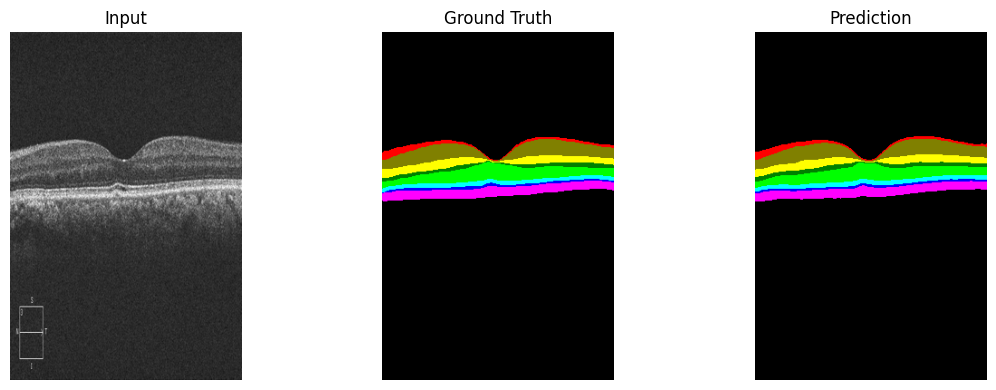

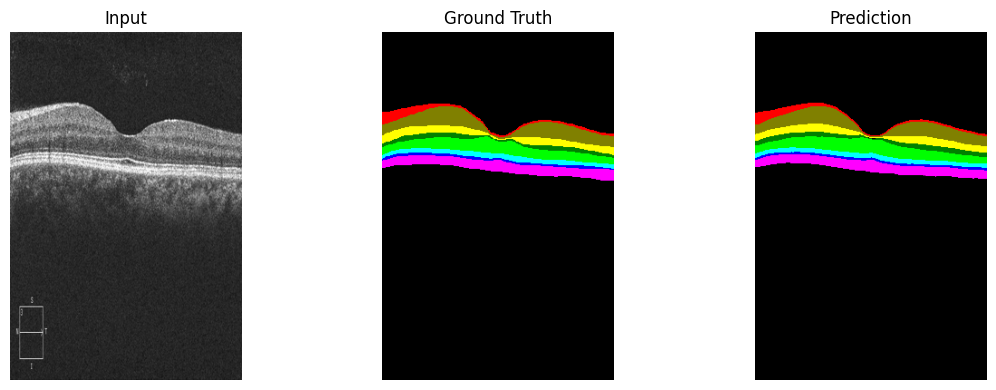

In [2]:
# === COMPLETE TESTING SCRIPT ===
# Computes NR206-style results:
# 1) Layer-wise Dice / IoU / PA as mean ± std over test images
# 2) Average Dice
# 3) mIoU
# 4) Acc (overall pixel accuracy per image)
# 5) mPA (mean pixel accuracy per image)
# 6) Excludes background from final reporting
# 7) Includes FLOPs, params, inference time, and optional visualization

import os
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

# =========================================================
# CONFIG
# =========================================================
img_height, img_width = 384, 256
test_img_dir = r"D:\layer\NR206\test"
test_lbl_dir = r"D:\layer\NR206\test_labels"
model_path = r"C:\Users\VPG\OCT_LAYER\EdgeFormer_Dice85_best_val_loss_0.072757.h5"

# Set these names according to your dataset label order
# First one should be background
LABEL_NAMES = [
    "BG",
    "NFL",
    "GCL+IPL",
    "INL",
    "OPL",
    "ONL",
    "ELM+IS",
    "OS",
    "RPE"
]

# =========================================================
# CUSTOM LAYER
# =========================================================
class PositionalEncoding(tf.keras.layers.Layer):
    def call(self, x):
        seq_len = tf.shape(x)[1]
        d_model = tf.shape(x)[2]
        pos = tf.cast(tf.range(seq_len)[:, tf.newaxis], tf.float32)
        i = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
        angle_rates = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        angle_rads = pos * angle_rates
        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])
        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = tf.expand_dims(pos_encoding, axis=0)
        return x + pos_encoding

# =========================================================
# EXTRACT LABEL COLORS
# =========================================================
def extract_unique_colors(mask_dir):
    unique_colors = set()
    for fname in os.listdir(mask_dir):
        if fname.lower().endswith(('.png', '.bmp', '.jpg', '.jpeg', '.tif', '.tiff')):
            mask = np.array(Image.open(os.path.join(mask_dir, fname)).convert('RGB'))
            colors = np.unique(mask.reshape(-1, 3), axis=0)
            for c in map(tuple, colors):
                unique_colors.add(c)
    return sorted(list(unique_colors))

UNIQUE_COLORS = extract_unique_colors(test_lbl_dir)
COLOR_TO_INDEX = {color: idx for idx, color in enumerate(UNIQUE_COLORS)}
INDEX_TO_COLOR = {idx: color for color, idx in COLOR_TO_INDEX.items()}
num_classes = len(COLOR_TO_INDEX)

if len(LABEL_NAMES) != num_classes:
    print(f"Warning: LABEL_NAMES length ({len(LABEL_NAMES)}) != num_classes ({num_classes})")
    LABEL_NAMES = [f"Class_{i}" for i in range(num_classes)]

print("Detected classes:", num_classes)
print("Detected colors:", UNIQUE_COLORS)
print("Label names:", LABEL_NAMES)

# =========================================================
# LOAD IMAGE-MASK PAIR
# =========================================================
def load_image_mask_pair(image_path, mask_path):
    image = Image.open(image_path).resize((img_width, img_height))
    image = np.array(image, dtype=np.float32) / 255.0

    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)

    mask = Image.open(mask_path).convert('RGB').resize(
        (img_width, img_height), resample=Image.NEAREST
    )
    mask = np.array(mask)

    mask_indexed = np.zeros((img_height, img_width), dtype=np.int32)
    for color, idx in COLOR_TO_INDEX.items():
        mask_indexed[np.all(mask == color, axis=-1)] = idx

    return image, mask_indexed

# =========================================================
# LOAD DATASET
# =========================================================
def load_dataset(image_dir, mask_dir):
    image_files = sorted([
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.lower().endswith(('.png', '.bmp', '.jpg', '.jpeg', '.tif', '.tiff'))
    ])
    mask_files = sorted([
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith(('.png', '.bmp', '.jpg', '.jpeg', '.tif', '.tiff'))
    ])

    if len(image_files) != len(mask_files):
        raise ValueError(f"Mismatch: {len(image_files)} images vs {len(mask_files)} masks")

    images, masks = [], []
    valid_names = []

    for img_path, msk_path in zip(image_files, mask_files):
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        msk_name = os.path.splitext(os.path.basename(msk_path))[0]

        img, msk = load_image_mask_pair(img_path, msk_path)
        images.append(img)
        masks.append(msk)
        valid_names.append((img_name, msk_name))

    return np.array(images), np.array(masks), valid_names

# =========================================================
# VISUALIZATION UTILITIES
# =========================================================
def label_to_color(mask):
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for label, color in INDEX_TO_COLOR.items():
        color_mask[mask == label] = color
    return color_mask

def plot_predictions(X, y_true, y_pred, n=3):
    n = min(n, len(X))
    for i in range(n):
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(X[i])
        plt.title("Input")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(label_to_color(y_true[i]))
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(label_to_color(y_pred[i]))
        plt.title("Prediction")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

# =========================================================
# METRIC FUNCTIONS (PER IMAGE)
# =========================================================
def dice_per_class_single(y_true, y_pred, num_classes, smooth=1e-6):
    scores = []
    for cls in range(num_classes):
        y_true_cls = (y_true == cls).astype(np.float32)
        y_pred_cls = (y_pred == cls).astype(np.float32)

        intersection = np.sum(y_true_cls * y_pred_cls)
        union = np.sum(y_true_cls) + np.sum(y_pred_cls)
        dice = (2.0 * intersection + smooth) / (union + smooth)
        scores.append(dice)
    return np.array(scores)

def iou_per_class_single(y_true, y_pred, num_classes, smooth=1e-6):
    scores = []
    for cls in range(num_classes):
        y_true_cls = (y_true == cls).astype(np.float32)
        y_pred_cls = (y_pred == cls).astype(np.float32)

        intersection = np.sum(y_true_cls * y_pred_cls)
        union = np.sum(y_true_cls) + np.sum(y_pred_cls) - intersection
        iou = (intersection + smooth) / (union + smooth)
        scores.append(iou)
    return np.array(scores)

def pixel_accuracy_per_class_single(y_true, y_pred, num_classes, smooth=1e-6):
    scores = []
    for cls in range(num_classes):
        cls_mask = (y_true == cls)
        total = np.sum(cls_mask)
        correct = np.sum((y_pred == cls) & cls_mask)
        acc = (correct + smooth) / (total + smooth)
        scores.append(acc)
    return np.array(scores)

def overall_pixel_accuracy_single(y_true, y_pred, smooth=1e-6):
    correct = np.sum(y_true == y_pred)
    total = y_true.size
    return (correct + smooth) / (total + smooth)

# =========================================================
# MODEL FLOPs
# =========================================================
def get_flops(model):
    try:
        from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

        input_shape = (1, img_height, img_width, 3)
        concrete_func = tf.function(lambda x: model(x))
        concrete_func = concrete_func.get_concrete_function(
            tf.TensorSpec(input_shape, tf.float32)
        )

        frozen_func = convert_variables_to_constants_v2(concrete_func)
        graph_def = frozen_func.graph.as_graph_def()

        with tf.Graph().as_default() as graph:
            tf.graph_util.import_graph_def(graph_def, name='')
            run_meta = tf.compat.v1.RunMetadata()
            opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

            flops = tf.compat.v1.profiler.profile(
                graph=graph,
                run_meta=run_meta,
                cmd='op',
                options=opts
            )

        return flops.total_float_ops
    except Exception as e:
        print("FLOPs calculation failed:", e)
        return None

# =========================================================
# MAIN
# =========================================================
print("Loading dataset...")
X_test, y_test, names = load_dataset(test_img_dir, test_lbl_dir)
print(f"Loaded test images: {X_test.shape}, masks: {y_test.shape}")

print("\nLoading model...")
model = load_model(
    model_path,
    compile=False,
    custom_objects={"PositionalEncoding": PositionalEncoding}
)

# =========================================================
# MODEL COMPLEXITY
# =========================================================
total_params = model.count_params()
weight_memory_mb = total_params * 4 / (1024 ** 2)  # float32 assumed
flops = get_flops(model)

print("\n===== Model Complexity =====")
print(f"Total Parameters : {total_params:,}")
print(f"Weight Memory    : {weight_memory_mb:.2f} MB")
if flops is not None:
    print(f"FLOPs            : {flops / 1e9:.2f} GFLOPs")

# =========================================================
# INFERENCE
# =========================================================
print("\nRunning inference...")
start_time = time.time()
y_pred_prob = model.predict(X_test, batch_size=1, verbose=1)
end_time = time.time()

total_inference_time = end_time - start_time
time_per_image = total_inference_time / len(X_test)
fps = 1.0 / time_per_image if time_per_image > 0 else 0.0

y_pred_label = np.argmax(y_pred_prob, axis=-1)

print("\n===== Inference Performance =====")
print(f"Total Time       : {total_inference_time:.4f} sec")
print(f"Time per Image   : {time_per_image * 1000:.2f} ms")
print(f"FPS              : {fps:.2f}")

# =========================================================
# IMAGE-WISE METRICS
# =========================================================
dice_all = []
iou_all = []
pa_class_all = []
acc_all = []
mpa_all = []

for i in range(len(y_test)):
    y_t = y_test[i]
    y_p = y_pred_label[i]

    dice_i = dice_per_class_single(y_t, y_p, num_classes)
    iou_i = iou_per_class_single(y_t, y_p, num_classes)
    pa_cls_i = pixel_accuracy_per_class_single(y_t, y_p, num_classes)
    acc_i = overall_pixel_accuracy_single(y_t, y_p)
    mpa_i = np.mean(pa_cls_i[1:]) if num_classes > 1 else np.mean(pa_cls_i)

    dice_all.append(dice_i)
    iou_all.append(iou_i)
    pa_class_all.append(pa_cls_i)
    acc_all.append(acc_i)
    mpa_all.append(mpa_i)

dice_all = np.array(dice_all)         # [N, C]
iou_all = np.array(iou_all)           # [N, C]
pa_class_all = np.array(pa_class_all) # [N, C]
acc_all = np.array(acc_all)           # [N]
mpa_all = np.array(mpa_all)           # [N]

# =========================================================
# MEAN ± STD PER CLASS
# =========================================================
dice_mean = np.mean(dice_all, axis=0)
dice_std  = np.std(dice_all, axis=0)

iou_mean = np.mean(iou_all, axis=0)
iou_std  = np.std(iou_all, axis=0)

pa_mean = np.mean(pa_class_all, axis=0)
pa_std  = np.std(pa_class_all, axis=0)

# =========================================================
# EXCLUDE BACKGROUND FOR FINAL REPORTING
# =========================================================
if num_classes > 1:
    report_names = LABEL_NAMES[1:]
    dice_mean_fg = dice_mean[1:]
    dice_std_fg  = dice_std[1:]

    iou_mean_fg = iou_mean[1:]
    iou_std_fg  = iou_std[1:]

    pa_mean_fg = pa_mean[1:]
    pa_std_fg  = pa_std[1:]
else:
    report_names = LABEL_NAMES
    dice_mean_fg = dice_mean
    dice_std_fg  = dice_std
    iou_mean_fg = iou_mean
    iou_std_fg  = iou_std
    pa_mean_fg = pa_mean
    pa_std_fg  = pa_std

# =========================================================
# OVERALL IMAGE-WISE METRICS
# =========================================================
avg_dice_per_image = np.mean(dice_all[:, 1:], axis=1) if num_classes > 1 else np.mean(dice_all, axis=1)
miou_per_image = np.mean(iou_all[:, 1:], axis=1) if num_classes > 1 else np.mean(iou_all, axis=1)

avg_dice_mean = np.mean(avg_dice_per_image)
avg_dice_std  = np.std(avg_dice_per_image)

miou_mean = np.mean(miou_per_image)
miou_std  = np.std(miou_per_image)

acc_mean = np.mean(acc_all)
acc_std  = np.std(acc_all)

mpa_mean = np.mean(mpa_all)
mpa_std  = np.std(mpa_all)

# =========================================================
# PRINT PER-LAYER RESULTS
# =========================================================
print("\n===== NR206-STYLE RESULTS (mean ± std, %) =====")
print("-" * 80)
print(f"{'Layer':12s} {'Dice (%)':20s} {'IoU (%)':20s} {'PA (%)':20s}")
print("-" * 80)

for i, name in enumerate(report_names):
    print(
        f"{name:12s} "
        f"{dice_mean_fg[i]*100:.2f} ± {dice_std_fg[i]*100:.2f}".ljust(20) + " "
        f"{iou_mean_fg[i]*100:.2f} ± {iou_std_fg[i]*100:.2f}".ljust(20) + " "
        f"{pa_mean_fg[i]*100:.2f} ± {pa_std_fg[i]*100:.2f}"
    )

print("-" * 80)
print(f"{'Average':12s} {avg_dice_mean*100:.2f} ± {avg_dice_std*100:.2f}")
print(f"{'mIoU':12s} {miou_mean*100:.2f} ± {miou_std*100:.2f}")
print(f"{'Acc':12s} {acc_mean*100:.2f} ± {acc_std*100:.2f}")
print(f"{'mPA':12s} {mpa_mean*100:.2f} ± {mpa_std*100:.2f}")
print("-" * 80)

# =========================================================
# OPTIONAL: SAVE RESULTS TO TXT
# =========================================================
save_txt_path = "nr206_results.txt"
with open(save_txt_path, "w") as f:
    f.write("===== NR206-STYLE RESULTS (mean ± std, %) =====\n")
    f.write("-" * 80 + "\n")
    f.write(f"{'Layer':12s} {'Dice (%)':20s} {'IoU (%)':20s} {'PA (%)':20s}\n")
    f.write("-" * 80 + "\n")

    for i, name in enumerate(report_names):
        line = (
            f"{name:12s} "
            f"{dice_mean_fg[i]*100:.2f} ± {dice_std_fg[i]*100:.2f}".ljust(20) + " "
            f"{iou_mean_fg[i]*100:.2f} ± {iou_std_fg[i]*100:.2f}".ljust(20) + " "
            f"{pa_mean_fg[i]*100:.2f} ± {pa_std_fg[i]*100:.2f}\n"
        )
        f.write(line)

    f.write("-" * 80 + "\n")
    f.write(f"{'Average':12s} {avg_dice_mean*100:.2f} ± {avg_dice_std*100:.2f}\n")
    f.write(f"{'mIoU':12s} {miou_mean*100:.2f} ± {miou_std*100:.2f}\n")
    f.write(f"{'Acc':12s} {acc_mean*100:.2f} ± {acc_std*100:.2f}\n")
    f.write(f"{'mPA':12s} {mpa_mean*100:.2f} ± {mpa_std*100:.2f}\n")
    f.write("-" * 80 + "\n")

    f.write("\n===== Model Complexity =====\n")
    f.write(f"Total Parameters : {total_params:,}\n")
    f.write(f"Weight Memory    : {weight_memory_mb:.2f} MB\n")
    if flops is not None:
        f.write(f"FLOPs            : {flops / 1e9:.2f} GFLOPs\n")

    f.write("\n===== Inference Performance =====\n")
    f.write(f"Total Time       : {total_inference_time:.4f} sec\n")
    f.write(f"Time per Image   : {time_per_image * 1000:.2f} ms\n")
    f.write(f"FPS              : {fps:.2f}\n")

print(f"\nResults saved to: {save_txt_path}")

# =========================================================
# OPTIONAL: LATEX-STYLE ROW OUTPUT
# =========================================================
print("\n===== LaTeX-style row =====")
latex_row = []
for i, name in enumerate(report_names):
    latex_row.append(f"{dice_mean_fg[i]*100:.1f} $\\pm$ {dice_std_fg[i]*100:.1f}")
print(" & ".join(latex_row))
print(f"Average Dice = {avg_dice_mean*100:.1f} $\\pm$ {avg_dice_std*100:.1f}")
print(f"mIoU = {miou_mean*100:.1f} $\\pm$ {miou_std*100:.1f}")
print(f"Acc = {acc_mean*100:.1f} $\\pm$ {acc_std*100:.1f}")
print(f"mPA = {mpa_mean*100:.1f} $\\pm$ {mpa_std*100:.1f}")

# =========================================================
# OPTIONAL VISUALIZATION
# =========================================================
plot_predictions(X_test, y_test, y_pred_label, n=3)